In [1]:
import tables
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

In [2]:
filelist = glob('/data/user/akatil/electron_neutrino/for_real/dataset_complete/enriched_h5/*028/*.h5')

In [3]:
len(filelist)

4900

In [3]:
np.random.seed(43)
filelist = np.random.choice(filelist, 2000, replace=False)

In [5]:
beta1_arr = ([])
ang_arr = ([])
daughter_arr = ([])
penergy_arr = ([])
senergy_arr = ([])

count = 0
for files in filelist:
    count+=1
    if count % 100 == 0:
        print(count)
    file = tables.open_file(files, mode='r')

    try:
        with tables.open_file(files, mode='r') as f:
            beta1 = f.get_node('/Beta1')  # This will raise NoSuchNodeError if not found
            # Process beta1 here
            beta1 = file.root.Beta1.col('value')
            daughter = file.root.daughter_type.col('value')    
            angle = file.root.median_angle.col('value')
            penergy = file.root.penergy.col('value')
            senergy = file.root.senergy.col('value')
            beta1_arr = np.append(beta1_arr,beta1)
            ang_arr = np.append(ang_arr,angle)
            daughter_arr = np.append(daughter_arr,daughter)
            penergy_arr = np.append(penergy_arr, penergy)
            senergy_arr = np.append(senergy_arr, senergy)
    except tables.NoSuchNodeError:
        print(f"Skipping file: {files} (no '/Beta1' node)")

    #print(file.__contains__(file.root.Beta1))
    #if file.__contains__(file.root.Beta1):
        

100


KeyboardInterrupt: 

In [3]:
beta1_list = []
ang_list = []
daughter_list = []
penergy_list = []
senergy_list = []

for count, filepath in enumerate(filelist, start=1):
    if count % 100 == 0:
        print(f"Processed {count} files")

    try:
        with tables.open_file(filepath, mode='r') as f:
            beta1 = f.root.Beta1[:]
            daughter = f.root.daughter_type[:]
            angle = f.root.median_angle[:]
            penergy = f.root.penergy[:]
            senergy = f.root.senergy[:]

            beta1_list.append(beta1)
            daughter_list.append(daughter)
            ang_list.append(angle)
            penergy_list.append(penergy)
            senergy_list.append(senergy)

    except tables.NoSuchNodeError:
        print(f"Skipping file: {filepath} (no '/Beta1' node)")
    except Exception as e:
        print(f"Error processing {filepath}: {e}")

# Convert lists to flat NumPy arrays
beta1_arr = np.concatenate(beta1_list)
daughter_arr = np.concatenate(daughter_list)
ang_arr = np.concatenate(ang_list)
penergy_arr = np.concatenate(penergy_list)
senergy_arr = np.concatenate(senergy_list)

Processed 100 files
Processed 200 files
Processed 300 files
Processed 400 files
Processed 500 files
Processed 600 files
Processed 700 files
Processed 800 files
Skipping file: /data/user/akatil/electron_neutrino/for_real/dataset_complete/enriched_h5/121028/upgrade_genie_level4_queso_121028_000441.h5 (no '/Beta1' node)
Processed 900 files
Processed 1000 files
Processed 1100 files
Processed 1200 files
Processed 1300 files
Processed 1400 files
Processed 1500 files
Processed 1600 files
Processed 1700 files
Processed 1800 files
Processed 1900 files
Processed 2000 files
Processed 2100 files
Processed 2200 files
Processed 2300 files
Processed 2400 files
Processed 2500 files
Processed 2600 files
Processed 2700 files
Processed 2800 files
Processed 2900 files
Processed 3000 files
Processed 3100 files
Processed 3200 files
Processed 3300 files
Processed 3400 files
Processed 3500 files
Processed 3600 files
Processed 3700 files
Processed 3800 files
Processed 3900 files
Processed 4000 files
Processed 

In [4]:
beta1_arr = beta1_arr['value']
daughter_arr = daughter_arr['value']
ang_arr = ang_arr['value']
penergy_arr = penergy_arr['value']
senergy_arr = senergy_arr['value']

([<matplotlib.patches.Wedge at 0x7fc8c8df5090>,
 [Text(-0.0506267513024354, 1.0988343515073422, 'CC NuE'),
  Text(-0.8689642957453644, -0.674463529569808, 'CC NuTau'),
  Text(-0.05478762914287501, -1.098634750812527, 'NC NuE'),
  Text(0.5257333974220738, -0.9662320605501785, 'NC NuMu'),
  Text(1.0094189108429998, -0.4371195058934477, 'NC NuTau')],
 [Text(-0.027614591619510215, 0.5993641917312775, '51.5%'),
  Text(-0.47398052495201687, -0.36788919794716796, '18.1%'),
  Text(-0.02988416135065909, -0.5992553186250146, '9.3%'),
  Text(0.2867636713211311, -0.5270356693910064, '8.1%'),
  Text(0.5505921331870908, -0.23842882139642602, '13.0%')])

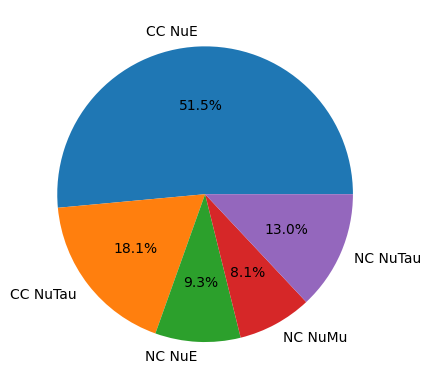

In [5]:
labels = 'CC NuE', 'CC NuTau', 'NC NuE', 'NC NuMu', 'NC NuTau'
sizes = [len(daughter_arr[(daughter_arr == 11) | (daughter_arr == -11)])/len(daughter_arr),
         len(daughter_arr[(daughter_arr == 15) | (daughter_arr == -15)])/len(daughter_arr),
         len(daughter_arr[(daughter_arr == 12) | (daughter_arr == -12)])/len(daughter_arr),
         len(daughter_arr[(daughter_arr == 14) | (daughter_arr == -14)])/len(daughter_arr),
         len(daughter_arr[(daughter_arr == 16) | (daughter_arr == -16)])/len(daughter_arr)]


fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%')

In [6]:
enriched_daughter = daughter_arr[(beta1_arr >= 0) & (beta1_arr <= 0.0002) & (ang_arr >= 0.62) & (ang_arr <= 0.77)]
enriched_penergy = penergy_arr[(beta1_arr >= 0) & (beta1_arr <= 0.0002) & (ang_arr >= 0.62) & (ang_arr <= 0.77)]
enriched_senergy = senergy_arr[(beta1_arr >= 0) & (beta1_arr <= 0.0002) & (ang_arr >= 0.62) & (ang_arr <= 0.77)]

([<matplotlib.patches.Wedge at 0x7fc8c90dd9d0>,
 [Text(-0.3163440022195528, 1.0535304799860874, 'CC NuE'),
  Text(-0.2670423704108384, -1.0670934225293307, 'CC NuTau'),
  Text(0.6805885326660622, -0.8641754736183251, 'NC NuE'),
  Text(0.9143567790693298, -0.6115158874223638, 'NC NuMu'),
  Text(1.072833588753002, -0.24295697323467533, 'NC NuTau')],
 [Text(-0.17255127393793784, 0.5746529890833204, '59.3%'),
  Text(-0.1456594747695482, -0.5820509577432712, '23.6%'),
  Text(0.371230108726943, -0.47136844015545004, '5.4%'),
  Text(0.49874006131054344, -0.3335541204121984, '4.6%'),
  Text(0.5851819575016374, -0.13252198540073198, '7.1%')])

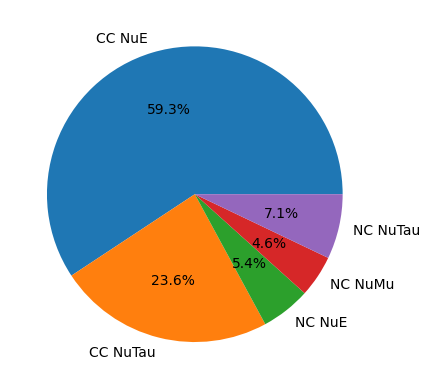

In [7]:
labels = 'CC NuE', 'CC NuTau', 'NC NuE', 'NC NuMu', 'NC NuTau'
sizes = [len(enriched_daughter[(enriched_daughter == 11) | (enriched_daughter == -11)])/len(enriched_daughter),
         len(enriched_daughter[(enriched_daughter == 15) | (enriched_daughter == -15)])/len(enriched_daughter),
         len(enriched_daughter[(enriched_daughter == 12) | (enriched_daughter == -12)])/len(enriched_daughter),
         len(enriched_daughter[(enriched_daughter == 14) | (enriched_daughter == -14)])/len(enriched_daughter),
         len(enriched_daughter[(enriched_daughter == 16) | (enriched_daughter == -16)])/len(enriched_daughter)]


fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%')

In [20]:
len(enriched_daughter)/len(daughter_arr) * 100

7.66234930309685

In [8]:
nue_beta1 = beta1_arr[(daughter_arr == 11) | (daughter_arr == -11)]
nutau_beta1 = beta1_arr[(daughter_arr == 15) | (daughter_arr == -15)]
nc_beta1 = beta1_arr[(daughter_arr != 15) & (daughter_arr != -15) & (daughter_arr != 11) & (daughter_arr != -11)]

nue_ang = ang_arr[(daughter_arr == 11) | (daughter_arr == -11)]
nutau_ang = ang_arr[(daughter_arr == 15) | (daughter_arr == -15)]
nc_ang = ang_arr[(daughter_arr != 15) & (daughter_arr != -15) & (daughter_arr != 11) & (daughter_arr != -11)]

nue_penergy = penergy_arr[(daughter_arr == 11) | (daughter_arr == -11)]
nutau_penergy = penergy_arr[(daughter_arr == 15) | (daughter_arr == -15)]
nc_penergy = penergy_arr[(daughter_arr != 15) & (daughter_arr != -15) & (daughter_arr != 11) & (daughter_arr != -11)]

nue_senergy = senergy_arr[(daughter_arr == 11) | (daughter_arr == -11)]
nutau_senergy = senergy_arr[(daughter_arr == 15) | (daughter_arr == -15)]
nc_senergy = senergy_arr[(daughter_arr != 15) & (daughter_arr != -15) & (daughter_arr != 11) & (daughter_arr != -11)]

Text(0.5, 0, 'beta1')

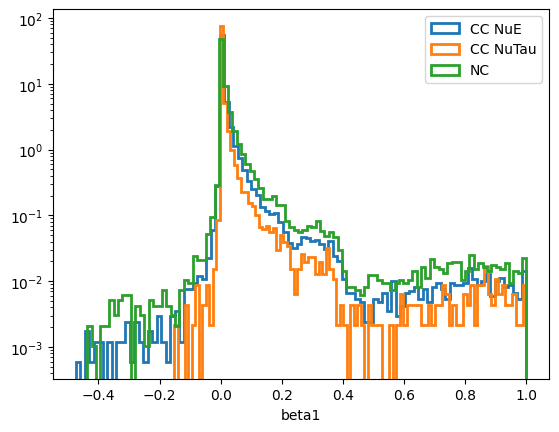

In [13]:
plt.hist(nue_beta1, bins=100, log=True, density=True, histtype='step', lw=2, label='CC NuE')
plt.hist(nutau_beta1, bins=100, log=True, density=True, histtype='step', lw=2, label='CC NuTau')
plt.hist(nc_beta1, bins=100, log=True, density=True, histtype='step', lw=2, label='NC')
plt.legend()
plt.xlabel('beta1')

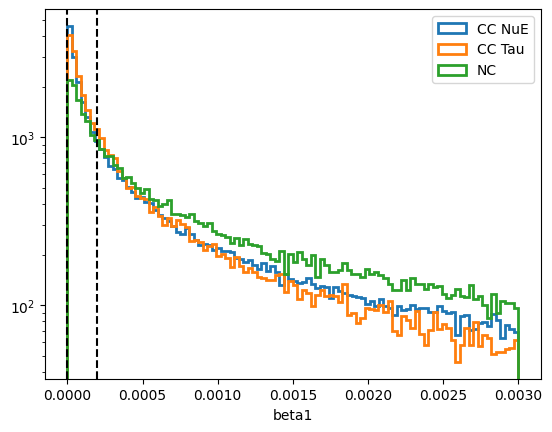

In [14]:
plt.hist(nue_beta1[(nue_beta1 >= 0) & (nue_beta1 <= 0.003)], bins=100, log=True, density=True, histtype='step', lw=2, label='CC NuE')
plt.hist(nutau_beta1[(nutau_beta1 >= 0) & (nutau_beta1 <= 0.003)], bins=100, log=True, density=True, histtype='step', lw=2, label='CC Tau')
plt.hist(nc_beta1[(nc_beta1 >= 0) & (nc_beta1 <= 0.003)], bins=100, log=True, density=True, histtype='step', lw=2, label='NC')
plt.axvline(x=0, c='k', ls='--')
plt.axvline(x=0.0002, c='k', ls='--')
plt.xlabel('beta1')
plt.legend()

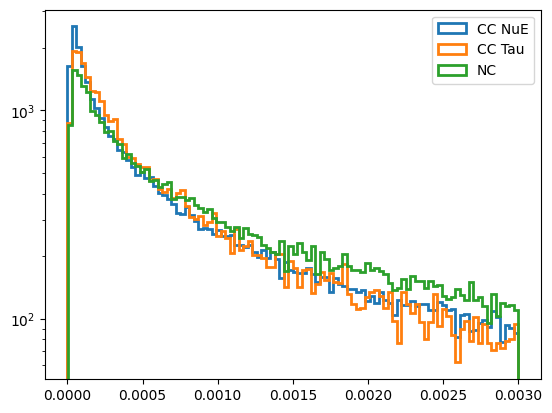

In [39]:
plt.hist(nue_beta1[(nue_beta1 >= 0) & (nue_beta1 <= 0.003) & (nue_penergy < 32)], bins=100, log=True, density=True, histtype='step', lw=2, label='CC NuE')
plt.hist(nutau_beta1[(nutau_beta1 >= 0) & (nutau_beta1 <= 0.003) & (nutau_penergy < 32)], bins=100, log=True, density=True, histtype='step', lw=2, label='CC Tau')
plt.hist(nc_beta1[(nc_beta1 >= 0) & (nc_beta1 <= 0.003) & (nc_penergy - nc_senergy < 32)], bins=100, log=True, density=True, histtype='step', lw=2, label='NC')
plt.legend()

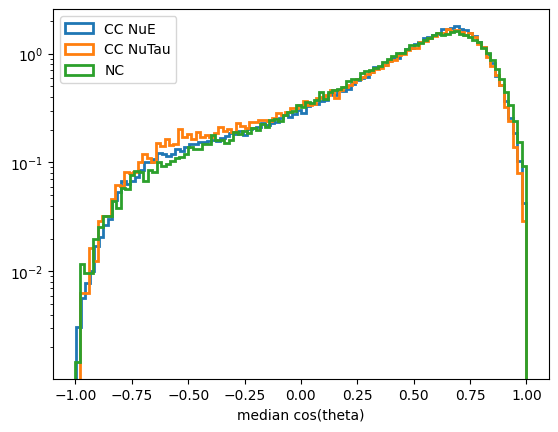

In [19]:
plt.hist(nue_ang, bins=100, log=True, density=True, histtype='step', lw=2, label='CC NuE')
plt.hist(nutau_ang, bins=100, log=True, density=True, histtype='step', lw=2, label='CC NuTau')
plt.hist(nc_ang, bins=100, log=True, density=True, histtype='step', lw=2, label='NC')
plt.xlabel('median cos(theta)')
plt.legend()

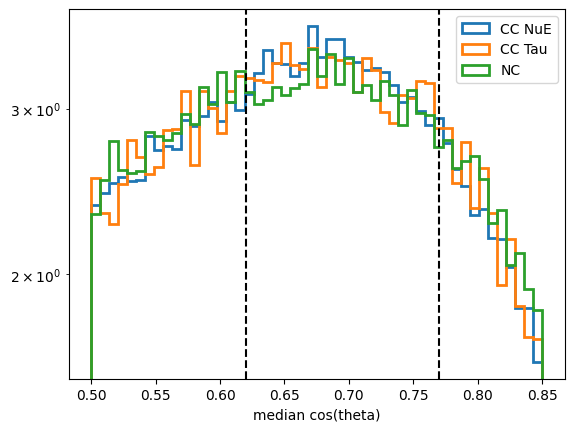

In [21]:
plt.hist(nue_ang[(nue_ang >= 0.5) & (nue_ang <= 0.85)], bins=50, log=True, density=True, histtype='step', lw=2, label='CC NuE')
plt.hist(nutau_ang[(nutau_ang >= 0.5) & (nutau_ang <= 0.85)], bins=50, log=True, density=True, histtype='step', lw=2, label='CC Tau')
plt.hist(nc_ang[(nc_ang >= 0.5) & (nc_ang <= 0.85)], bins=50, log=True, density=True, histtype='step', lw=2, label='NC')
plt.xlabel('median cos(theta)')
plt.axvline(x=0.62, c='k', ls='--')
plt.axvline(x=0.77, c='k', ls='--')
plt.legend()

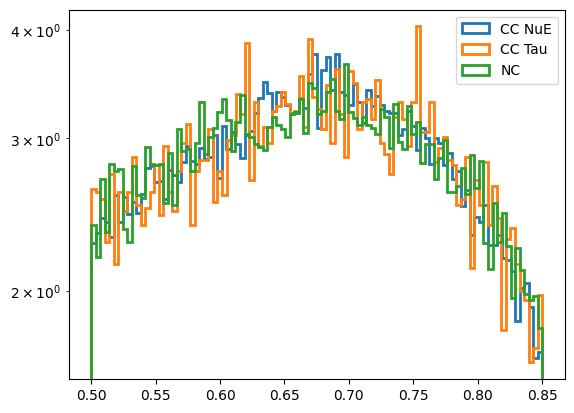

In [42]:
plt.hist(nue_ang[(nue_ang >= 0.5) & (nue_ang <= 0.85) & (nue_penergy < 32)], bins=100, log=True, density=True, histtype='step', lw=2, label='CC NuE')
plt.hist(nutau_ang[(nutau_ang >= 0.5) & (nutau_ang <= 0.85) & (nutau_penergy < 32)], bins=100, log=True, density=True, histtype='step', lw=2, label='CC Tau')
plt.hist(nc_ang[(nc_ang >= 0.5) & (nc_ang <= 0.85)& (nc_penergy - nc_senergy < 32)], bins=100, log=True, density=True, histtype='step', lw=2, label='NC')
plt.legend()


In [31]:
nue_inelasticity = (nue_penergy - nue_senergy)/nue_penergy
nutau_inelasticity = (nutau_penergy - nutau_senergy)/nutau_penergy

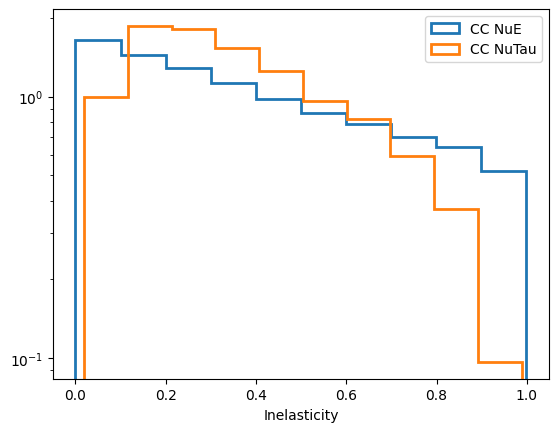

In [36]:
plt.hist(nue_inelasticity, histtype='step', log=True, density=True, lw=2, label='CC NuE')
plt.hist(nutau_inelasticity, histtype='step', log=True, density=True, lw=2, label='CC NuTau')
plt.xlabel('Inelasticity')
plt.legend()

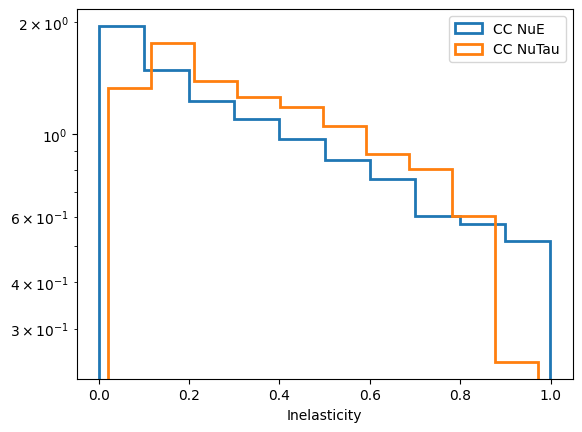

In [37]:
plt.hist(nue_inelasticity[(nue_beta1 >= 0) & (nue_beta1 <= 0.0002) & (nue_ang >= 0.62) & (nue_ang <= 0.77)], histtype='step', log=True, density=True, lw=2, label='CC NuE')
plt.hist(nutau_inelasticity[(nutau_beta1 >= 0) & (nutau_beta1 <= 0.0002) & (nutau_ang >= 0.62) & (nutau_ang <= 0.77)], histtype='step', log=True, density=True, lw=2, label='CC NuTau')
plt.xlabel('Inelasticity')
plt.legend()

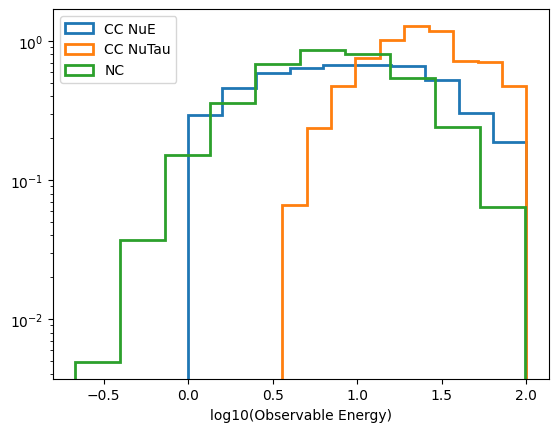

In [43]:
plt.hist(np.log10(nue_penergy), histtype='step', log=True, density=True, lw=2, label='CC NuE')
plt.hist(np.log10(nutau_penergy), histtype='step', log=True, density=True, lw=2, label='CC NuTau')
plt.hist(np.log10(nc_penergy-nc_senergy), histtype='step', log=True, density=True, lw=2, label='NC')
plt.xlabel('log10(Observable Energy)')
plt.legend()

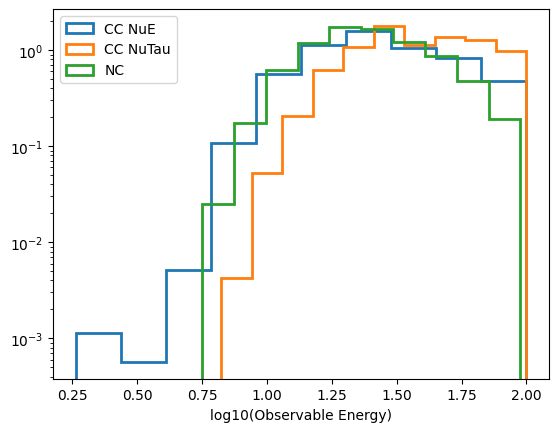

In [44]:
plt.hist(np.log10(nue_penergy[(nue_beta1 >= 0) & (nue_beta1 <= 0.0002) & (nue_ang >= 0.62) & (nue_ang <= 0.77)]), histtype='step', log=True, density=True, lw=2, label='CC NuE')
plt.hist(np.log10(nutau_penergy[(nutau_beta1 >= 0) & (nutau_beta1 <= 0.0002) & (nutau_ang >= 0.62) & (nutau_ang <= 0.77)]), histtype='step', log=True, density=True, lw=2, label='CC NuTau')
plt.hist(np.log10(nc_penergy-nc_senergy)[(nc_beta1 >= 0) & (nc_beta1 <= 0.0002) & (nc_ang >= 0.62) & (nc_ang <= 0.77)], histtype='step', log=True, density=True, lw=2, label='NC')
plt.xlabel('log10(Observable Energy)')
plt.legend()

In [43]:
enriched_daughter = daughter_arr[(beta1_arr >= 0) & (beta1_arr <= 0.0002) & (ang_arr >= 0.62) & (ang_arr <= 0.77)]
enriched_penergy = penergy_arr[(beta1_arr >= 0) & (beta1_arr <= 0.0002) & (ang_arr >= 0.62) & (ang_arr <= 0.77)]
enriched_senergy = senergy_arr[(beta1_arr >= 0) & (beta1_arr <= 0.0002) & (ang_arr >= 0.62) & (ang_arr <= 0.77)]

In [44]:
len(enriched_daughter)

17097

In [45]:
len(enriched_daughter[(enriched_daughter == 11) | (enriched_daughter == -11)])/len(enriched_daughter)

0.5928525472305083

In [46]:
electron_beta1 = beta1_arr[(daughter_arr == 11) | (daughter_arr == -11)]
other_beta1 = beta1_arr[(daughter_arr != 11) & (daughter_arr != -11)]

([<matplotlib.patches.Wedge at 0x7fd39151c710>,
 [Text(-0.05062654554184085, 1.09883436098736, 'CC NuE'),
  Text(-0.8689645799105357, -0.6744631634573577, 'CC NuTau'),
  Text(0.6337550709544963, -0.8990853741661364, 'NC')],
 [Text(-0.027614479386458644, 0.5993641969021963, '51.5%'),
  Text(-0.4739806799512012, -0.3678889982494678, '18.1%'),
  Text(0.34568458415699793, -0.4904102040906198, '30.5%')])

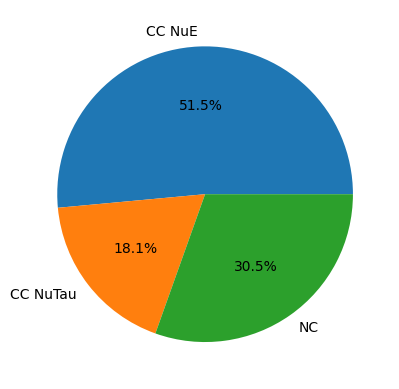

In [47]:
labels = 'CC NuE', 'CC NuTau', 'NC'
sizes = [len(nue_penergy)/len(daughter_arr),
         len(nutau_penergy)/len(daughter_arr),
         len(nc_penergy)/len(daughter_arr)]


fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%')

In [ ]:
labels = 'CC NuE', 'CC NuTau', 'NC'
sizes = [len(nue_penergy)/len(daughter_arr),
         len(nutau_penergy)/len(daughter_arr),
         len(nc_penergy)/len(daughter_arr)]


fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%')

([<matplotlib.patches.Wedge at 0x7fd391c09d10>,
 [Text(-0.18469841750983038, 1.084383001789204, 'CC NuE'),
  Text(-0.6970323236062491, -0.8509676491195617, 'CC NuTau'),
  Text(0.7218491308298494, -0.8300203806655541, 'NC')],
 [Text(-0.10074459136899837, 0.5914816373395657, '55.4%'),
  Text(-0.38019944923977217, -0.4641641722470336, '17.4%'),
  Text(0.39373588954355415, -0.4527383894539385, '27.2%')])

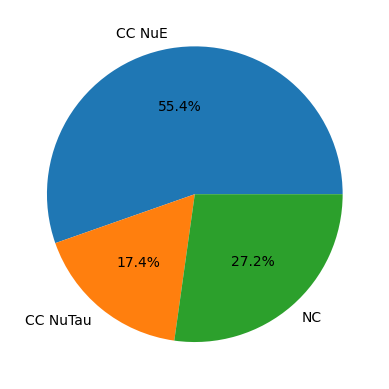

In [36]:
labels = 'CC NuE', 'CC NuTau', 'NC'
sizes = [len(nue_penergy[(nue_beta1 >= 0) & (nue_beta1 <= 0.003) & (nue_ang >= 0.5) & (nue_ang <= 0.85) & (nue_penergy < 32)])/len(enriched_daughter),
         len(nutau_penergy[(nutau_beta1 >= 0) & (nutau_beta1 <= 0.003) & (nutau_ang >= 0.5) & (nutau_ang <= 0.85) & (nutau_penergy < 32)])/len(enriched_daughter),
         len(nc_penergy[(nc_beta1 >= 0) & (nc_beta1 <= 0.003) & (nc_ang >= 0.5) & (nc_ang <= 0.85) & (nc_penergy - nc_senergy < 32)])/len(enriched_daughter)]


fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%')

([<matplotlib.patches.Wedge at 0x7fb8a36f9910>,
 [Text(-0.0506267513024354, 1.0988343515073422, 'CC NuE'),
  Text(-0.8689642957453644, -0.674463529569808, 'CC NuTau'),
  Text(-0.05478762914287501, -1.098634750812527, 'NC NuE'),
  Text(0.5257333974220738, -0.9662320605501785, 'NC NuMu'),
  Text(1.0094189108429998, -0.4371195058934477, 'NC NuTau')],
 [Text(-0.027614591619510215, 0.5993641917312775, '51.5%'),
  Text(-0.47398052495201687, -0.36788919794716796, '18.1%'),
  Text(-0.02988416135065909, -0.5992553186250146, '9.3%'),
  Text(0.2867636713211311, -0.5270356693910064, '8.1%'),
  Text(0.5505921331870908, -0.23842882139642602, '13.0%')])

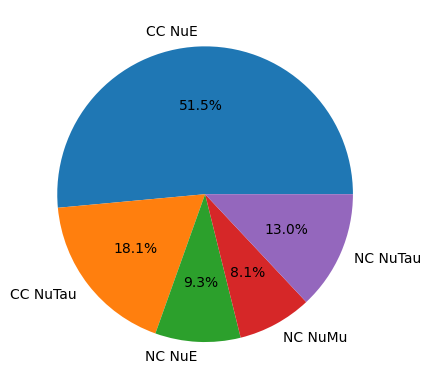

In [25]:
labels = 'CC NuE', 'CC NuTau', 'NC NuE', 'NC NuMu', 'NC NuTau'
sizes = [len(daughter_arr[(daughter_arr == 11) | (daughter_arr == -11)])/len(daughter_arr),
         len(daughter_arr[(daughter_arr == 15) | (daughter_arr == -15)])/len(daughter_arr),
         len(daughter_arr[(daughter_arr == 12) | (daughter_arr == -12)])/len(daughter_arr),
         len(daughter_arr[(daughter_arr == 14) | (daughter_arr == -14)])/len(daughter_arr),
         len(daughter_arr[(daughter_arr == 16) | (daughter_arr == -16)])/len(daughter_arr)]


fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%')

In [26]:
len(enriched_daughter)/len(daughter_arr) * 100

7.66234930309685

([<matplotlib.patches.Wedge at 0x7fb8a38b8910>,
 [Text(-0.3163440022195528, 1.0535304799860874, 'CC NuE'),
  Text(-0.2670423704108384, -1.0670934225293307, 'CC NuTau'),
  Text(0.6805885326660622, -0.8641754736183251, 'NC NuE'),
  Text(0.9143567790693298, -0.6115158874223638, 'NC NuMu'),
  Text(1.072833588753002, -0.24295697323467533, 'NC NuTau')],
 [Text(-0.17255127393793784, 0.5746529890833204, '59.3%'),
  Text(-0.1456594747695482, -0.5820509577432712, '23.6%'),
  Text(0.371230108726943, -0.47136844015545004, '5.4%'),
  Text(0.49874006131054344, -0.3335541204121984, '4.6%'),
  Text(0.5851819575016374, -0.13252198540073198, '7.1%')])

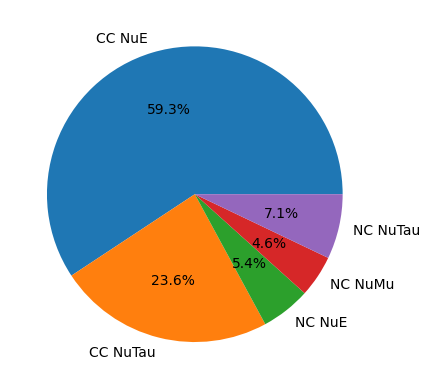

In [27]:
labels = 'CC NuE', 'CC NuTau', 'NC NuE', 'NC NuMu', 'NC NuTau'
sizes = [len(enriched_daughter[(enriched_daughter == 11) | (enriched_daughter == -11)])/len(enriched_daughter),
         len(enriched_daughter[(enriched_daughter == 15) | (enriched_daughter == -15)])/len(enriched_daughter),
         len(enriched_daughter[(enriched_daughter == 12) | (enriched_daughter == -12)])/len(enriched_daughter),
         len(enriched_daughter[(enriched_daughter == 14) | (enriched_daughter == -14)])/len(enriched_daughter),
         len(enriched_daughter[(enriched_daughter == 16) | (enriched_daughter == -16)])/len(enriched_daughter)]


fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%')

(array([2.0000e+00, 1.0000e+00, 0.0000e+00, 2.0000e+00, 2.0000e+00,
        5.0000e+00, 3.0000e+00, 5.0000e+00, 6.0000e+00, 6.0000e+00,
        0.0000e+00, 4.0000e+00, 3.0000e+00, 1.0000e+00, 5.0000e+00,
        4.0000e+00, 4.0000e+00, 7.0000e+00, 4.0000e+00, 4.0000e+00,
        2.0000e+00, 7.0000e+00, 1.2000e+01, 9.0000e+00, 2.5000e+01,
        2.3000e+01, 2.2000e+01, 5.5000e+01, 9.4000e+01, 3.0300e+02,
        8.1558e+04, 1.1712e+04, 4.5140e+03, 2.3170e+03, 1.3970e+03,
        9.8600e+02, 6.9900e+02, 5.2300e+02, 4.2100e+02, 2.9100e+02,
        2.0400e+02, 2.1500e+02, 2.2300e+02, 1.6000e+02, 1.6400e+02,
        1.0100e+02, 7.6000e+01, 6.4000e+01, 6.6000e+01, 6.9000e+01,
        7.9000e+01, 8.0000e+01, 9.1000e+01, 6.1000e+01, 6.5000e+01,
        6.3000e+01, 4.9000e+01, 3.2000e+01, 1.5000e+01, 8.0000e+00,
        1.1000e+01, 7.0000e+00, 9.0000e+00, 8.0000e+00, 1.5000e+01,
        1.3000e+01, 1.1000e+01, 9.0000e+00, 1.0000e+01, 7.0000e+00,
        1.0000e+01, 1.3000e+01, 1.1000e+01, 1.10

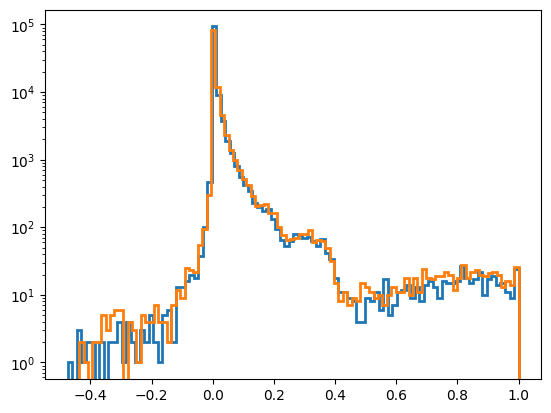

In [28]:
plt.hist(electron_beta1, bins=100, log=True, histtype='step', lw=2)
plt.hist(other_beta1, bins=100, log=True, histtype='step', lw=2)

(array([5958., 5097., 3845., 3053., 2631., 2177., 2026., 1784., 1569.,
        1517., 1394., 1251., 1116., 1057., 1011.,  924.,  880.,  899.,
         772.,  786.,  712.,  687.,  741.,  634.,  657.,  634.,  612.,
         581.,  550.,  537.,  503.,  525.,  499.,  453.,  457.,  437.,
         399.,  437.,  390.,  403.,  390.,  381.,  368.,  345.,  337.,
         325.,  328.,  357.,  268.,  336.,  307.,  314.,  306.,  288.,
         297.,  257.,  306.,  282.,  268.,  265.,  263.,  307.,  247.,
         240.,  231.,  229.,  257.,  245.,  248.,  248.,  234.,  235.,
         192.,  188.,  224.,  202.,  218.,  223.,  202.,  180.,  204.,
         215.,  200.,  192.,  182.,  175.,  171.,  171.,  182.,  191.,
         185.,  169.,  165.,  145.,  167.,  142.,  156.,  156.,  158.,
         156.]),
 array([9.35785152e-08, 3.00847435e-05, 6.00759086e-05, 9.00670736e-05,
        1.20058239e-04, 1.50049404e-04, 1.80040569e-04, 2.10031734e-04,
        2.40022899e-04, 2.70014064e-04, 3.00005229e-04, 3.

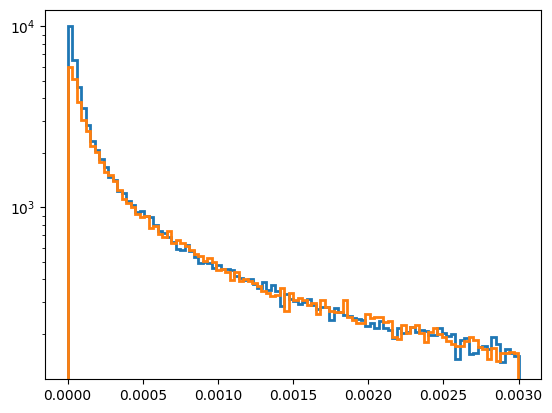

In [29]:
plt.hist(electron_beta1[(electron_beta1 >= 0) & (electron_beta1 <= 0.003)], bins=100, log=True, density=False, histtype='step', lw=2)
plt.hist(other_beta1[(other_beta1 >= 0) & (other_beta1 <= 0.003)], bins=100, log=True, density=False, histtype='step', lw=2)

In [45]:
electron_ang = ang_arr[(daughter_arr == 11) | (daughter_arr == -11)] & (penergy_arr < 32 )]
other_ang = ang_arr[(daughter_arr != 11) & (daughter_arr != -11) ]

#electron_ang = ang_arr[(daughter_arr == 11) | (daughter_arr == -11)]
#other_ang = ang_arr[(daughter_arr != 11) & (daughter_arr != -11)]

In [43]:
len(electron_ang)

111290

In [46]:
len(electron_ang)

114835

(array([3.000e+00, 2.000e+01, 1.800e+01, 2.800e+01, 3.700e+01, 6.000e+01,
        6.800e+01, 7.000e+01, 9.900e+01, 1.040e+02, 1.290e+02, 1.410e+02,
        1.750e+02, 1.850e+02, 1.920e+02, 1.860e+02, 2.040e+02, 2.000e+02,
        2.490e+02, 2.500e+02, 2.630e+02, 2.600e+02, 2.720e+02, 3.110e+02,
        3.100e+02, 3.250e+02, 3.180e+02, 3.220e+02, 3.450e+02, 3.480e+02,
        3.970e+02, 3.580e+02, 3.950e+02, 3.570e+02, 3.730e+02, 4.140e+02,
        4.470e+02, 4.470e+02, 4.080e+02, 4.870e+02, 4.660e+02, 5.000e+02,
        4.790e+02, 5.480e+02, 5.470e+02, 5.300e+02, 6.130e+02, 6.420e+02,
        6.510e+02, 7.370e+02, 7.120e+02, 7.650e+02, 7.610e+02, 8.100e+02,
        9.190e+02, 8.420e+02, 9.680e+02, 9.670e+02, 9.970e+02, 1.068e+03,
        1.156e+03, 1.244e+03, 1.254e+03, 1.368e+03, 1.466e+03, 1.505e+03,
        1.589e+03, 1.636e+03, 1.765e+03, 1.889e+03, 2.010e+03, 2.136e+03,
        2.172e+03, 2.343e+03, 2.503e+03, 2.558e+03, 2.692e+03, 2.855e+03,
        3.014e+03, 3.170e+03, 3.307e+0

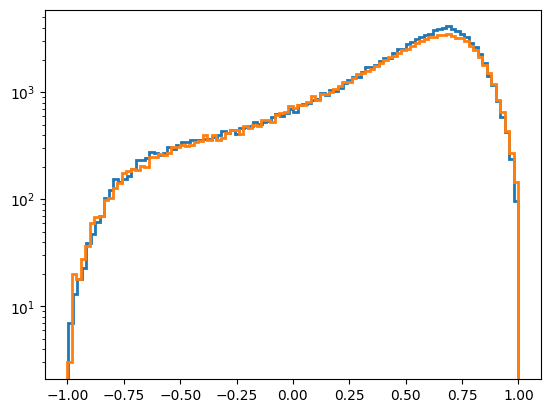

In [39]:
plt.hist(electron_ang, bins=100, log=True, histtype='step', lw=2)
plt.hist(other_ang, bins=100, log=True, histtype='step', lw=2)

(array([454., 421., 474., 419., 481., 461., 485., 445., 442., 522., 473.,
        480., 513., 485., 510., 484., 500., 526., 483., 554., 551., 554.,
        493., 524., 591., 561., 557., 546., 571., 565., 574., 552., 597.,
        598., 598., 559., 570., 563., 547., 590., 600., 583., 591., 601.,
        583., 593., 619., 563., 641., 627., 585., 591., 639., 611., 597.,
        592., 624., 610., 582., 560., 607., 582., 575., 578., 572., 566.,
        518., 588., 547., 537., 577., 560., 590., 528., 552., 560., 491.,
        524., 536., 492., 477., 456., 497., 485., 473., 459., 482., 449.,
        393., 444., 405., 396., 390., 375., 375., 359., 343., 332., 330.,
        319.]),
 array([0.50000422, 0.50350414, 0.50700405, 0.51050397, 0.51400388,
        0.5175038 , 0.52100371, 0.52450363, 0.52800354, 0.53150346,
        0.53500338, 0.53850329, 0.54200321, 0.54550312, 0.54900304,
        0.55250295, 0.55600287, 0.55950279, 0.5630027 , 0.56650262,
        0.57000253, 0.57350245, 0.57700236, 0.

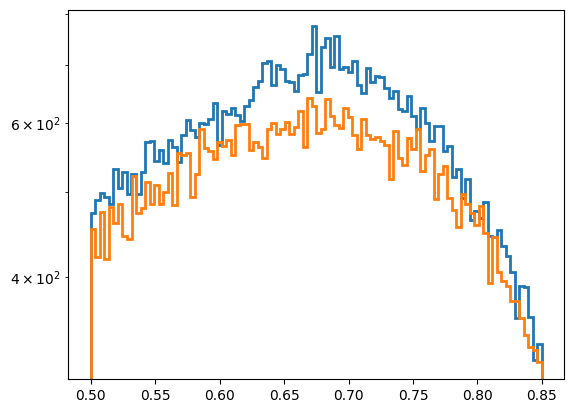

In [40]:
plt.hist(electron_ang[(electron_ang >= 0.5) & (electron_ang <= 0.85)], bins=100, log=True, histtype='step', lw=2)
plt.hist(other_ang[(other_ang >= 0.5) & (other_ang <= 0.85)], bins=100, log=True, histtype='step', lw=2)

(array([0.02508762, 0.00836254, 0.04181271, 0.1003505 , 0.13380066,
        0.29268895, 0.35958929, 0.51847758, 0.97005482, 0.96169228,
        1.41326952, 1.16239327, 1.69759593, 1.80630897, 1.71432102,
        1.69759593, 1.68087085, 1.58888289, 1.47180731, 1.17911836,
        0.97005482, 1.05368023, 0.81952907, 0.76099128, 0.56865283,
        0.53520266, 0.32613912, 0.35958929, 0.13380066, 0.08362542]),
 array([0.7491756 , 0.79009992, 0.83102424, 0.87194857, 0.91287289,
        0.95379721, 0.99472153, 1.03564586, 1.07657018, 1.1174945 ,
        1.15841882, 1.19934315, 1.24026747, 1.28119179, 1.32211611,
        1.36304044, 1.40396476, 1.44488908, 1.48581341, 1.52673773,
        1.56766205, 1.60858637, 1.6495107 , 1.69043502, 1.73135934,
        1.77228366, 1.81320799, 1.85413231, 1.89505663, 1.93598095,
        1.97690528]),
 [<matplotlib.patches.Polygon at 0x7fb8a2f79550>])

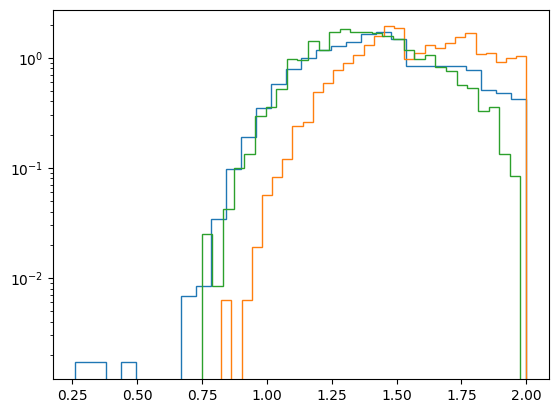

In [33]:
plt.hist(np.log10(enriched_penergy[(enriched_daughter == 11) | (enriched_daughter == -11)]), bins=30, log=True, density=True, histtype='step', label='')
plt.hist(np.log10(enriched_penergy[(enriched_daughter == 15) | (enriched_daughter == -15)]), bins=30, log=True, density=True, histtype='step')
plt.hist(np.log10(enriched_penergy[(enriched_daughter != 15) & (enriched_daughter != -15) & (enriched_daughter != 11) & (enriched_daughter != -11)]-enriched_senergy[(enriched_daughter != 15) & (enriched_daughter != -15) & (enriched_daughter != 11) & (enriched_daughter != -11)]), bins=30, log=True, density=True, histtype='step')